In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, integrate

$$
E + S \underset{k_{1inv}}{\overset{k_1}{\rightleftharpoons}} ES \overset{k_{cat}}{\rightarrow} E + P
$$

In [2]:
def system(t, x, k1, k1inv, kcat):
    return np.array([
        - k1 * x[0] * x[1] + k1inv * x[2] + kcat * x[2],
        - k1 * x[0] * x[1] + k1inv * x[2],
        + k1 * x[0] * x[1] - k1inv * x[2] - kcat * x[2],
        + kcat * x[2]
    ])

In [3]:
t = np.linspace(0, 250, 100)

In [4]:
x0 = np.array([1e-6, 1e-2, 0.0, 0.0])

In [5]:
ks = np.array([1e-1, 1e-2, 1e-3])

In [6]:
Ss = np.linspace(0, 1, 21)

In [7]:
vs = []
sols = []
for S in Ss:
    x0 = np.array([1e-6, S, 0.0, 0.0])
    solution = integrate.solve_ivp(system, [t.min(), t.max()], y0=x0, args=ks, t_eval=t, atol=1e-16, rtol=1e-12)
    sols.append(solution)
    v = system(t, solution.y, *ks)
    vs.append(v[3,-1])

In [8]:
def model(x, vmax, kM):
    return vmax * x / (x + kM)

In [9]:
popt, pcov = optimize.curve_fit(model, Ss, vs)
vhat = model(Ss, *popt)

In [10]:
np.sum(((vhat[1:] - vs[1:]) / vs[1:]) ** 2)

0.0001669695933667395

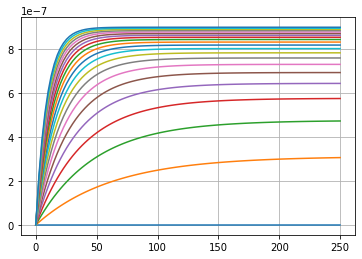

In [11]:
fig, axe = plt.subplots()
for sol in sols:
    axe.plot(t, sol.y[2])
axe.grid()

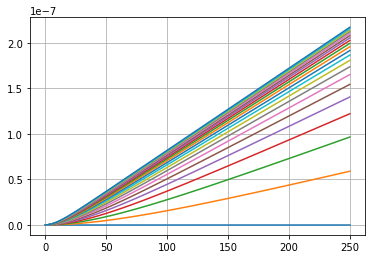

In [12]:
fig, axe = plt.subplots()
for sol in sols:
    axe.plot(t, sol.y[3])
axe.grid()

In [13]:
Slin = np.linspace(Ss.min(), Ss.max(), 200)
vlin = model(Slin, *popt)

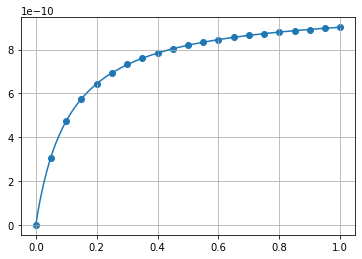

In [14]:
fig, axe = plt.subplots()
axe.scatter(Ss, vs)
axe.plot(Slin, vlin)
axe.grid()